# Our classifier study

## Importations

In [85]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.effects


from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

from classification.datasets import Dataset
from classification.utils.audio_student import AudioUtil, Feature_vector_DS
from classification.utils.utils import accuracy
from classification.utils.plots import (
    plot_decision_boundaries,
    plot_specgram,
    show_confusion_matrix,
)

import pickle

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
GPU Available: []


## Config

In [86]:
class Config:
    """Centralized configuration"""
    
    # Audio parameters
    SAMPLE_RATE = 11025
    DURATION_MS = 950
    N_FFT = 512
    N_MEL = 20
    STEP_SIZE = 51
    
    # Data augmentation flags
    AUG_TIME_SHIFT = True
    AUG_PITCH_SHIFT = True
    AUG_TIME_STRETCH = True
    AUG_NOISE = True
    AUG_SPEC_MASKING = True
    
    # Augmentation parameters
    PITCH_SHIFT_RANGE = (-2, 2)  # semitones
    TIME_STRETCH_RANGE = (0.9, 1.1)
    NOISE_SIGMA = 0.05
    
    # Model architecture
    DENSE_UNITS = [256, 128, 64]
    DROPOUT_RATE = 0.4
    ACTIVATION = 'relu'
    
    # Training
    BATCH_SIZE = 64
    EPOCHS = 400
    LEARNING_RATE = 0.001
    VALIDATION_SPLIT = 0.2
    TEST_SPLIT = 0.2
    
    # Callbacks
    EARLY_STOPPING_PATIENCE = 100
    REDUCE_LR_PATIENCE = 25
    REDUCE_LR_FACTOR = 0.3
    
    # Paths
    MODEL_DIR = "./data/models/models_cnn/"
    
    # Decision strategy
    DECISION_STRATEGY = 'max_probability'
    CONFIDENCE_THRESHOLD = 0.6
    TEMPERATURE = 1.0

config = Config()

## Data augmentation

In [87]:
class AdvancedAudioAugmentation:
    """Advanced augmentation: time-shift, pitch-shift, time-stretch"""
    
    @staticmethod
    def time_shift(audio, shift_max=0.2):
        sig, sr = audio
        shift_amount = int(np.random.uniform(-shift_max, shift_max) * len(sig))
        sig_shifted = np.roll(sig, shift_amount)
        return (sig_shifted, sr)
    
    @staticmethod
    def pitch_shift(audio, n_steps_range=(-2, 2)):
        sig, sr = audio
        n_steps = np.random.uniform(n_steps_range[0], n_steps_range[1])
        sig_shifted = librosa.effects.pitch_shift(sig, sr=sr, n_steps=n_steps)
        return (sig_shifted, sr)
    
    @staticmethod
    def time_stretch(audio, rate_range=(0.9, 1.1)):
        sig, sr = audio
        rate = np.random.uniform(rate_range[0], rate_range[1])
        sig_stretched = librosa.effects.time_stretch(sig, rate=rate)
        
        if len(sig_stretched) > len(sig):
            sig_stretched = sig_stretched[:len(sig)]
        elif len(sig_stretched) < len(sig):
            sig_stretched = np.pad(sig_stretched, (0, len(sig) - len(sig_stretched)))
        return (sig_stretched, sr)
    
    @staticmethod
    def apply_augmentation_pipeline(audio, config):
        """Apply full augmentation pipeline"""
        if config.AUG_TIME_SHIFT and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.time_shift(audio)
        
        if config.AUG_PITCH_SHIFT and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.pitch_shift(
                audio, n_steps_range=config.PITCH_SHIFT_RANGE)
        
        if config.AUG_TIME_STRETCH and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.time_stretch(
                audio, rate_range=config.TIME_STRETCH_RANGE)
        
        if config.AUG_NOISE and np.random.random() > 0.5:
            audio = AudioUtil.add_noise(audio, sigma=config.NOISE_SIGMA)
        
        return audio


class AugmentedFeatureVectorDS(Feature_vector_DS):
    """Extended Dataset with advanced augmentation + FIXES"""
    
    def __init__(self, *args, use_advanced_aug=False, config=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.use_advanced_aug = use_advanced_aug
        self.config = config or Config()
    
    def get_audiosignal(self, cls_index):
        audio_file = self.dataset[cls_index]
        aud = AudioUtil.open(audio_file)
        aud = AudioUtil.resample(aud, self.sr)
        
        if self.use_advanced_aug:
            aud = AdvancedAudioAugmentation.apply_augmentation_pipeline(
                aud, self.config)
        
        if self.data_aug is not None:
            if "add_bg" in self.data_aug:
                aud = AudioUtil.add_bg(aud, self.dataset, num_sources=1,
                                      max_ms=self.duration, amplitude_limit=0.1)
            if "echo" in self.data_aug:
                aud = AudioUtil.echo(aud)
            if "noise" in self.data_aug:
                aud = AudioUtil.add_noise(aud, sigma=0.05)
            if "scaling" in self.data_aug:
                aud = AudioUtil.scaling(aud, scaling_limit=5)
        
        aud = (aud[0] / (np.max(np.abs(aud[0])) + 1e-8), aud[1])
        return aud
    
    def __getitem__(self, cls_index):
        aud = self.get_audiosignal(cls_index)
        sgram = AudioUtil.melspectrogram(aud, Nmel=self.nmel, Nft=self.Nft)
        
        if self.use_advanced_aug and self.config.AUG_SPEC_MASKING:
            if np.random.random() > 0.5:
                sgram = AudioUtil.spectro_aug_timefreq_masking(
                    sgram, max_mask_pct=0.1, n_freq_masks=2, n_time_masks=2)
        
        return sgram
    
    def treat_spec(self, sgram):
        n_cols = sgram.shape[1]
        # S'assurer que le spectrogram est assez grand -> sinon pad
        if n_cols < self.ncol:
            pad_width = self.ncol - n_cols
            sgram = np.pad(sgram, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)
            n_cols = sgram.shape[1]
        
        # Calculer les indices pour le sliding window
        indexes = np.arange(0, n_cols - self.ncol + 1, self.step, dtype=int)
        
        # S'assurer qu'il y a au moins un index
        if len(indexes) == 0:
            indexes = np.array([0])
        
        # Extraire les fenêtres
        sgrams = []
        for i in indexes:
            window = sgram[:, i : i + self.ncol]
            # Double check: s'assurer que la fenêtre a la bonne taille
            if window.shape[1] < self.ncol:
                pad_width = self.ncol - window.shape[1]
                window = np.pad(window, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)
            sgrams.append(window)
        
        sgrams = np.array(sgrams)
        fv = sgrams.reshape(sgrams.shape[0], -1)
        
        if self.normalize:
            # Éviter division par zéro
            norms = np.linalg.norm(fv, axis=1, keepdims=True)
            norms[norms == 0] = 1.0
            fv = fv / norms
        
        if self.pca is not None:
            fv = np.array([self.pca.transform([i])[0] for i in fv])
        
        return fv

## Data preparation

In [88]:
def prepare_dataset(dataset, config, use_augmentation=True, n_augmentations=5, custom_test_dir=None):
    """
    Prepare train and test datasets with augmentation applied only to training set.
    
    Parameters:
    -----------
    dataset : Dataset
        Main dataset object containing training audio files
    config : Config
        Configuration object with audio processing parameters
    use_augmentation : bool
        Whether to apply data augmentation to training set
    n_augmentations : int
        Number of augmented copies to generate per training sample
    custom_test_dir : str or None
        Path to directory containing custom test audio files.
        If None, test set is extracted from main dataset via train_test_split.
        If provided, entire dataset is used for training and test comes from custom directory.
        Expected structure: custom_test_dir/classname/*.wav
    
    Returns:
    --------
    X_train_norm, X_test_norm, y_train_cat, y_test_cat, y_train, y_test, classnames
    """
    from collections import Counter
    
    classnames = dataset.list_classes()
    print("\n" + "="*80)
    print("DATA PREPARATION")
    print("="*80)
    
    # Display raw audio file counts
    print("\nRaw audio files (before augmentation):")
    total_files = 0
    for classname in classnames:
        n = dataset.naudio[classname]
        total_files += n
        print(f"  {classname:<15}: {n:>4} files")
    print(f"  {'TOTAL':<15}: {total_files:>4} files")
    
    # Extract original features from main dataset (will be used for training)
    print("\nExtracting original features from main dataset...")
    myds_original = AugmentedFeatureVectorDS(
        dataset, Nft=config.N_FFT, nmel=config.N_MEL,
        duration=config.DURATION_MS, step=config.STEP_SIZE,
        use_advanced_aug=False, config=config
    )
    X_full, y_full = myds_original.get_feature_vectors()
    print(f"  Extracted: {len(X_full)} feature vectors")
    
    # Convert labels to numeric
    label_to_idx = {label: idx for idx, label in enumerate(classnames)}
    y_full_numeric = np.array([label_to_idx[label] for label in y_full])
    
    # Handle test set
    if custom_test_dir is not None:
        print(f"\nUsing custom test set from: {custom_test_dir}")
        
        # All main dataset goes to training
        X_train_base = X_full
        y_train_base = y_full_numeric
        
        # Load custom test set
        X_test_list = []
        y_test_list = []
        
        for classname in classnames:
            class_dir = os.path.join(custom_test_dir, classname)
            if not os.path.exists(class_dir):
                print(f"  Warning: {class_dir} not found, skipping")
                continue
            
            audio_files = sorted([f for f in os.listdir(class_dir) if f.endswith('.wav')])
            print(f"  {classname:<15}: {len(audio_files):>4} test files")
            
            for audio_file in audio_files:
                audio_path = os.path.join(class_dir, audio_file)
                
                # Load and process audio
                aud = AudioUtil.open(audio_path)
                aud = AudioUtil.resample(aud, config.SAMPLE_RATE)
                sgram = AudioUtil.melspectrogram(aud, Nmel=config.N_MEL, Nft=config.N_FFT)
                
                # Extract features using same sliding window
                myds_temp = AugmentedFeatureVectorDS(
                    dataset, Nft=config.N_FFT, nmel=config.N_MEL,
                    duration=config.DURATION_MS, step=config.STEP_SIZE,
                    use_advanced_aug=False, config=config
                )
                features = myds_temp.treat_spec(sgram)
                
                X_test_list.extend(features)
                y_test_list.extend([label_to_idx[classname]] * len(features))
        
        X_test = np.array(X_test_list)
        y_test = np.array(y_test_list)
        print(f"\nCustom test set: {len(X_test)} feature vectors")
        
    else:
        print("\nSplitting dataset into train/test (80/20)...")
        X_train_base, X_test, y_train_base, y_test = train_test_split(
            X_full, y_full_numeric, 
            test_size=config.TEST_SPLIT,
            stratify=y_full_numeric, 
            random_state=42
        )
        print(f"  Train base: {len(X_train_base)} vectors")
        print(f"  Test set:   {len(X_test)} vectors")
    
    # Apply augmentation ONLY to training set
    all_X_train = [X_train_base]
    all_y_train = [y_train_base]
    
    if use_augmentation and n_augmentations > 0:
        print(f"\nApplying {n_augmentations} augmentation passes to TRAINING set only...")
        
        # Create temporary dataset for augmentation
        # We need to map back from feature vectors to original audio files
        # This is complex, so we'll re-extract with augmentation
        
        for i in range(n_augmentations):
            print(f"  Pass {i+1}/{n_augmentations}...")
            myds_aug = AugmentedFeatureVectorDS(
                dataset, Nft=config.N_FFT, nmel=config.N_MEL,
                duration=config.DURATION_MS, step=config.STEP_SIZE,
                use_advanced_aug=True, config=config
            )
            X_aug, y_aug = myds_aug.get_feature_vectors()
            y_aug_numeric = np.array([label_to_idx[label] for label in y_aug])
            
            if custom_test_dir is None:
                # Need to split augmented data the same way
                X_aug_train, _, y_aug_train, _ = train_test_split(
                    X_aug, y_aug_numeric,
                    test_size=config.TEST_SPLIT,
                    stratify=y_aug_numeric,
                    random_state=42
                )
                all_X_train.append(X_aug_train)
                all_y_train.append(y_aug_train)
            else:
                # All augmented data goes to training
                all_X_train.append(X_aug)
                all_y_train.append(y_aug_numeric)
            
            print(f"    Generated: {len(all_X_train[-1])} vectors")
    
    # Concatenate all training data
    X_train = np.concatenate(all_X_train, axis=0)
    y_train = np.concatenate(all_y_train, axis=0)
    
    # Display final statistics
    print("\n" + "="*80)
    print("FINAL DATASET STATISTICS")
    print("="*80)
    
    print("\nTraining set (with augmentation):")
    train_counts = Counter(y_train)
    for i, classname in enumerate(classnames):
        count = train_counts.get(i, 0)
        print(f"  {classname:<15}: {count:>5} vectors")
    print(f"  {'TOTAL':<15}: {len(X_train):>5} vectors")
    
    print("\nTest set (NO augmentation):")
    test_counts = Counter(y_test)
    for i, classname in enumerate(classnames):
        count = test_counts.get(i, 0)
        print(f"  {classname:<15}: {count:>5} vectors")
    print(f"  {'TOTAL':<15}: {len(X_test):>5} vectors")
    
    augmentation_factor = len(X_train) / len(X_train_base)
    print(f"\nAugmentation factor: x{augmentation_factor:.1f}")
    print("="*80)
    
    # L2 Normalization
    print("\nApplying L2 normalization...")
    X_train_norm = X_train / (np.linalg.norm(X_train, axis=1, keepdims=True) + 1e-8)
    X_test_norm = X_test / (np.linalg.norm(X_test, axis=1, keepdims=True) + 1e-8)
    
    # One-hot encoding
    y_train_cat = to_categorical(y_train, num_classes=len(classnames))
    y_test_cat = to_categorical(y_test, num_classes=len(classnames))
    
    return X_train_norm, X_test_norm, y_train_cat, y_test_cat, y_train, y_test, classnames

```python
# Cas 1: Test set depuis le dataset principal (train_test_split)
X_train, X_test, y_train_cat, y_test_cat, y_train, y_test, classnames = prepare_dataset(
    dataset, 
    config, 
    use_augmentation=True, 
    n_augmentations=5,
    custom_test_dir=None
)

# Cas 2: Test set depuis un dossier custom d'enregistrements
X_train, X_test, y_train_cat, y_test_cat, y_train, y_test, classnames = prepare_dataset(
    dataset, 
    config, 
    use_augmentation=True, 
    n_augmentations=5,
    custom_test_dir="./data/recorded_test_samples"
)
```

**Structure attendue du dossier custom:**
```
recorded_test_samples/
├── chainsaw/
│   ├── test_001.wav
│   ├── test_002.wav
│   └── ...
├── fire/
│   ├── test_001.wav
│   └── ...
├── fireworks/
│   └── ...
└── gunshot/
    └── ...

## Linear CNN Model

In [89]:
def build_linear_cnn_model(input_shape, num_classes, config):
    """
    Small 2D-CNN that accepts flattened feature vectors (e.g. 400 = N_MEL * time_steps).
    It reshapes the input to (N_MEL, time_steps, 1) when possible and applies Conv2D layers.
    """
    model = models.Sequential(name="SimpleCNN")
    model.add(layers.Input(shape=input_shape, name="input"))

    # Try to reshape flattened vector into (n_mel, time_steps, 1)
    if len(input_shape) == 1:
        n_feat = input_shape[0]
        n_mel = getattr(config, "N_MEL", 20)
        if n_feat % n_mel == 0:
            time_steps = n_feat // n_mel
            model.add(layers.Reshape((n_mel, time_steps, 1), name="reshape_to_spec"))
        else:
            # fallback: treat as 1D sequence with single channel
            model.add(layers.Reshape((n_feat, 1, 1), name="reshape_fallback"))
    else:
        # if input_shape already multi-dim, keep it as-is
        pass

    # Convolutional blocks
    model.add(layers.Conv2D(16, (3, 3), padding="same", activation=config.ACTIVATION, name="conv_1"))
    model.add(layers.BatchNormalization(name="bn_1"))
    model.add(layers.MaxPool2D((2, 2), name="pool_1"))

    model.add(layers.Conv2D(32, (3, 3), padding="same", activation=config.ACTIVATION, name="conv_2"))
    model.add(layers.BatchNormalization(name="bn_2"))
    model.add(layers.MaxPool2D((2, 2), name="pool_2"))

    model.add(layers.Conv2D(64, (3, 3), padding="same", activation=config.ACTIVATION, name="conv_3"))
    model.add(layers.BatchNormalization(name="bn_3"))
    model.add(layers.GlobalAveragePooling2D(name="gap"))

    model.add(layers.Dense(64, activation=config.ACTIVATION, name="dense_1"))
    model.add(layers.Dropout(config.DROPOUT_RATE, name="dropout_1"))
    model.add(layers.Dense(num_classes, activation="softmax", name="output"))

    # Compile (we train with one-hot labels in the pipeline)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=2)]
    )

    model.summary()
    print(f"\nTotal parameters: {model.count_params():,}")
    print(f"Model size: ~{model.count_params() * 4 / 1024:.2f} KB (FP32)")

    return model

## Training

In [90]:
def train_model(model, X_train, y_train, X_val, y_val, config):
    """Train with callbacks"""
    print("\n" + "="*80)
    print("TRAINING")
    print("="*80)
    
    os.makedirs(config.MODEL_DIR, exist_ok=True)
    
    callback_list = [
        callbacks.EarlyStopping(monitor='val_loss', patience=config.EARLY_STOPPING_PATIENCE,
                               restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=config.REDUCE_LR_FACTOR,
                                   patience=config.REDUCE_LR_PATIENCE, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint(config.MODEL_DIR + 'best_model.h5',
                                 monitor='val_accuracy', save_best_only=True, verbose=1)
    ]
    
    #print(f"Epochs: {config.EPOCHS}, Batch: {config.BATCH_SIZE}")
    #print(f"Train: {len(X_train)}, Val: {len(X_val)}")
    
    history = model.fit(
        X_train, y_train, batch_size=config.BATCH_SIZE, epochs=config.EPOCHS,
        validation_data=(X_val, y_val), callbacks=callback_list, verbose=1
    )
    
    with open(config.MODEL_DIR + 'history.pkl', 'wb') as f:
        pickle.dump(history.history, f)
    
    return history

## Decision strategies

In [91]:
class DecisionStrategy:
    """Advanced decision strategies for classification"""
    
    @staticmethod
    def max_probability(probs, threshold=None):
        """Select class with max probability"""
        pred_class = np.argmax(probs)
        if threshold and probs[pred_class] < threshold:
            return -1  # Uncertain
        return pred_class
    
    @staticmethod
    def temperature_scaling(probs, temperature=1.0):
        """Apply temperature scaling for calibration"""
        logits = np.log(probs + 1e-10)
        scaled_logits = logits / temperature
        return np.exp(scaled_logits) / np.sum(np.exp(scaled_logits))
    
    @staticmethod
    def top_k_voting(probs, k=2):
        """Top-k predictions with gap analysis"""
        top_k_idx = np.argsort(probs)[-k:][::-1]
        top_k_probs = probs[top_k_idx]
        return {
            'classes': top_k_idx,
            'probabilities': top_k_probs,
            'gap': top_k_probs[0] - top_k_probs[1] if k > 1 else 1.0
        }

## Evaluation

In [92]:
def evaluate_model_full(model, X_train, y_train, X_val, y_val, X_test, y_test, classnames, config):
    """
    Comprehensive evaluation with confusion matrices for train, validation and test sets.
    
    Parameters:
    -----------
    model : keras.Model
        Trained model
    X_train, y_train : arrays
        Training data (one-hot encoded labels)
    X_val, y_val : arrays
        Validation data (one-hot encoded labels)
    X_test, y_test : arrays
        Test data (one-hot encoded labels)
    classnames : list
        List of class names
    config : Config
        Configuration object
    
    Returns:
    --------
    dict : Metrics for all three sets
    """
    print("\n" + "="*80)
    print("COMPREHENSIVE EVALUATION")
    print("="*80)
    
    # Predictions for all three sets
    y_train_pred_probs = model.predict(X_train, verbose=0)
    y_train_pred = np.argmax(y_train_pred_probs, axis=1)
    y_train_true = np.argmax(y_train, axis=1)
    
    y_val_pred_probs = model.predict(X_val, verbose=0)
    y_val_pred = np.argmax(y_val_pred_probs, axis=1)
    y_val_true = np.argmax(y_val, axis=1)
    
    y_test_pred_probs = model.predict(X_test, verbose=0)
    y_test_pred = np.argmax(y_test_pred_probs, axis=1)
    y_test_true = np.argmax(y_test, axis=1)
    
    # Compute accuracies
    train_acc = np.mean(y_train_pred == y_train_true)
    val_acc = np.mean(y_val_pred == y_val_true)
    test_acc = np.mean(y_test_pred == y_test_true)
    
    # Summary
    print("\nAccuracy Summary:")
    print(f"  Training:   {100 * train_acc:.2f}%")
    print(f"  Validation: {100 * val_acc:.2f}%")
    print(f"  Test:       {100 * test_acc:.2f}%")
    print(f"\nOverfitting Analysis:")
    print(f"  Train-Val gap:  {100 * (train_acc - val_acc):.2f}%")
    print(f"  Train-Test gap: {100 * (train_acc - test_acc):.2f}%")
    
    if train_acc - val_acc > 0.15:
        print("  WARNING: Significant overfitting detected (>15% gap)")
    elif train_acc - val_acc > 0.10:
        print("  CAUTION: Moderate overfitting (>10% gap)")
    else:
        print("  GOOD: Minimal overfitting (<10% gap)")
    
    # Create figure with 3 confusion matrices
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    datasets = [
        ("Training Set", y_train_true, y_train_pred, train_acc),
        ("Validation Set", y_val_true, y_val_pred, val_acc),
        ("Test Set", y_test_true, y_test_pred, test_acc)
    ]
    
    for idx, (title, y_true, y_pred, acc) in enumerate(datasets):
        ax = axes[idx]
        
        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        
        # Plot
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
        ax.set_title(f'{title}\nAccuracy: {100*acc:.1f}%', fontsize=14, fontweight='bold')
        
        # Colorbar
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # Ticks
        tick_marks = np.arange(len(classnames))
        ax.set_xticks(tick_marks)
        ax.set_xticklabels(classnames, rotation=45, ha='right', fontsize=10)
        ax.set_yticks(tick_marks)
        ax.set_yticklabels(classnames, fontsize=10)
        
        # Text annotations
        thresh = cm.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, format(cm[i, j], 'd'),
                       ha="center", va="center",
                       color="white" if cm[i, j] > thresh else "black",
                       fontsize=11)
        
        ax.set_ylabel('True Label', fontweight='bold', fontsize=11)
        ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(config.MODEL_DIR + 'confusion_matrices_all.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Per-class metrics for test set
    print("\n" + "="*80)
    print("PER-CLASS METRICS (Test Set)")
    print("="*80)
    
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test_true, y_test_pred, labels=range(len(classnames)), average=None
    )
    
    print(f"\n{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-" * 65)
    for i, cls in enumerate(classnames):
        print(f"{cls:<15} {precision[i]:>10.3f} {recall[i]:>10.3f} "
              f"{f1[i]:>10.3f} {int(support[i]):>10}")
    
    # Macro averages
    print("-" * 65)
    print(f"{'Macro Avg':<15} {np.mean(precision):>10.3f} {np.mean(recall):>10.3f} "
          f"{np.mean(f1):>10.3f} {int(np.sum(support)):>10}")
    
    # Confidence analysis
    print("\n" + "="*80)
    print("CONFIDENCE ANALYSIS")
    print("="*80)
    
    for name, probs in [("Training", y_train_pred_probs), 
                        ("Validation", y_val_pred_probs), 
                        ("Test", y_test_pred_probs)]:
        max_probs = np.max(probs, axis=1)
        print(f"\n{name} Set:")
        print(f"  Mean confidence:   {np.mean(max_probs):.3f}")
        print(f"  Median confidence: {np.median(max_probs):.3f}")
        print(f"  Min confidence:    {np.min(max_probs):.3f}")
        print(f"  Max confidence:    {np.max(max_probs):.3f}")
    
    return {
        'train': {'accuracy': train_acc, 'predictions': y_train_pred, 'probabilities': y_train_pred_probs},
        'val': {'accuracy': val_acc, 'predictions': y_val_pred, 'probabilities': y_val_pred_probs},
        'test': {'accuracy': test_acc, 'predictions': y_test_pred, 'probabilities': y_test_pred_probs}
    }

## Visualisation

In [93]:
def plot_training_history(history, config):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(config.MODEL_DIR + 'training_history.png', dpi=300)
    plt.show()
    
    best_epoch = np.argmax(history.history['val_accuracy'])
    print(f"\nBest val accuracy: {100*history.history['val_accuracy'][best_epoch]:.2f}% "
          f"at epoch {best_epoch + 1}")

## Main pipeline

In [94]:
def main_pipeline(dataset, config):
    """Complete training pipeline"""
    print("\n" + "="*80)
    print("CNN AUDIO CLASSIFIER - PIPELINE")
    print("="*80)
    
    # Prepare data
    X_train, X_test, y_train_cat, y_test_cat, y_train, y_test, classnames = prepare_dataset(
        dataset, 
        config, 
        use_augmentation=True, 
        n_augmentations=20,
        custom_test_dir=None
    )
    
    # Validation split
    X_train_final, X_val, y_train_final, y_val = train_test_split(
        X_train, y_train_cat, test_size=config.VALIDATION_SPLIT,
        stratify=y_train, random_state=42
    )
    
    print(f"\nSplits: Train={X_train_final.shape[0]}, "
          f"Val={X_val.shape[0]}, Test={X_test.shape[0]}")
    
    # Build model
    model = build_linear_cnn_model(
        input_shape=(X_train.shape[1],),
        num_classes=len(classnames),
        config=config
    )
    
    # Train
    history = train_model(model, X_train_final, y_train_final, X_val, y_val, config)
    
    # Plot history
    plot_training_history(history, config)
    
    # Load best model and evaluate
    best_model = keras.models.load_model(config.MODEL_DIR + 'best_model.h5')
    metrics = evaluate_model(best_model, X_test, y_test_cat, classnames, config)
    
    # Save model
    print("\n" + "="*80)
    print("SAVING MODEL")
    print("="*80)
    
    best_model.save(config.MODEL_DIR + 'final_model.h5')
    print(f"Keras model saved: {config.MODEL_DIR}final_model.h5")
    
    # Save config
    model_config = {
        'classnames': classnames,
        'input_shape': (X_train.shape[1],),
        'n_mel': config.N_MEL,
        'n_fft': config.N_FFT,
        'sample_rate': config.SAMPLE_RATE,
        'test_accuracy': metrics['accuracy']
    }
    with open(config.MODEL_DIR + 'model_config.pkl', 'wb') as f:
        pickle.dump(model_config, f)
    
    # Export to TensorFlow Lite (for embedded)
    try:
        converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        tflite_model = converter.convert()
        
        with open(config.MODEL_DIR + 'model.tflite', 'wb') as f:
            f.write(tflite_model)
        print(f"TFLite model: {config.MODEL_DIR}model.tflite ({len(tflite_model)/1024:.2f} KB)")
    except Exception as e:
        print(f"TFLite conversion error: {e}")
    
    print("\n" + "="*80)
    print("COMPLETE - Ready for MCU+FPGA deployment!")
    print(f"Test Accuracy: {100 * metrics['accuracy']:.2f}%")
    print("="*80)
    
    return best_model, metrics, classnames

##  INFERENCE FOR EMBEDDED DEPLOYMENT

In [95]:
def inference_for_embedded(model, feature_vector, classnames, config):
    """
    Optimized inference for embedded deployment.
    Receives feature vectors from LimeSDR wireless link.
    """
    if len(feature_vector.shape) == 1:
        feature_vector = feature_vector.reshape(1, -1)
    
    # L2 normalization
    feature_vector_norm = feature_vector / \
        (np.linalg.norm(feature_vector, axis=1, keepdims=True) + 1e-8)
    
    # Predict
    prob_vector = model.predict(feature_vector_norm, verbose=0)[0]
    
    # Decision strategy
    predicted_idx = DecisionStrategy.max_probability(
        prob_vector, threshold=config.CONFIDENCE_THRESHOLD
    )
    
    # Top-k
    top_k = DecisionStrategy.top_k_voting(prob_vector, k=3)
    
    return {
        'predicted_class': classnames[predicted_idx] if predicted_idx >= 0 else 'UNCERTAIN',
        'confidence': prob_vector[predicted_idx] if predicted_idx >= 0 else 0.0,
        'probability_vector': prob_vector,
        'top_3': [(classnames[i], prob_vector[i]) for i in top_k['classes']],
        'decision_gap': top_k['gap']
    }


CNN AUDIO CLASSIFIER - PIPELINE

DATA PREPARATION

Raw audio files (before augmentation):
  chainsaw       :   40 files
  fire           :   40 files
  fireworks      :   40 files
  gunshot        :   40 files
  TOTAL          :  160 files

Extracting original features from main dataset...
  Extracted: 527 feature vectors

Splitting dataset into train/test (80/20)...
  Train base: 421 vectors
  Test set:   106 vectors

Applying 20 augmentation passes to TRAINING set only...
  Pass 1/20...
    Generated: 421 vectors
  Pass 2/20...
    Generated: 421 vectors
  Pass 3/20...
    Generated: 421 vectors
  Pass 4/20...
    Generated: 421 vectors
  Pass 5/20...
    Generated: 421 vectors
  Pass 6/20...
    Generated: 421 vectors
  Pass 7/20...
    Generated: 421 vectors
  Pass 8/20...
    Generated: 421 vectors
  Pass 9/20...
    Generated: 421 vectors
  Pass 10/20...
    Generated: 421 vectors
  Pass 11/20...
    Generated: 421 vectors
  Pass 12/20...
    Generated: 421 vectors
  Pass 13/20.

Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_to_spec (Reshape)       │ (None, 20, 20, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 20, 20, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 20, 20, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 10, 10, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 10, 10, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 5, 5, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 5, 5, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,164 (110.02 KB)

 Trainable params: 27,940 (109.14 KB)

...

111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9977 - loss: 0.0105 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.8502 - val_loss: 1.0019 - val_top_k_categorical_accuracy: 0.9644 - learning_rate: 9.0000e-05
Epoch 79/400
109/111 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9973 - loss: 0.0124 - top_k_categorical_accuracy: 1.0000
Epoch 79: val_accuracy did not improve from 0.85020
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9976 - loss: 0.0120 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.8378 - val_loss: 1.2037 - val_top_k_categorical_accuracy: 0.9661 - learning_rate: 9.0000e-05
Epoch 80/400
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9981 - loss: 0.0106 - top_k_categorical_accuracy: 1.0000
Epoch 80: val_accuracy did not improve from 0.85020
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9980 - loss: 0.0103 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.7631 - val_loss: 2.6550 - val_top_k_categorical_accuracy: 0.8722 

[15:56:04] WARNING  You are saving your model as an HDF5 file via `model.save()` or                ]8;id=183302;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py\saving_api.py]8;;\:]8;id=371647;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py#83\83]8;;\
                    `keras.saving.save_model(model)`. This file format is considered legacy. We                    
                    recommend using instead the native Keras format, e.g.                                          
                    `model.save('my_model.keras')` or `keras.saving.save_model(model,                              
                    'my_model.keras')`.                                                                            

111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9986 - loss: 0.0088 - top_k_categorical_accuracy: 0.9999 - val_accuracy: 0.8643 - val_loss: 0.8453 - val_top_k_categorical_accuracy: 0.9678 - learning_rate: 9.0000e-05
Epoch 83/400
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9985 - loss: 0.0088 - top_k_categorical_accuracy: 0.9998
Epoch 83: val_accuracy did not improve from 0.86433
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9979 - loss: 0.0091 - top_k_categorical_accuracy: 0.9999 - val_accuracy: 0.6851 - val_loss: 2.2267 - val_top_k_categorical_accuracy: 0.8960 - learning_rate: 9.0000e-05
Epoch 84/400
108/111 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9981 - loss: 0.0098 - top_k_categorical_accuracy: 1.0000
Epoch 84: val_accuracy did not improve from 0.86433
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9984 - loss: 0.0084 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.7569 - val_loss: 1.4888 - val_top_k_categorical_accuracy: 0.9344 

[15:56:45] WARNING  You are saving your model as an HDF5 file via `model.save()` or                ]8;id=476195;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py\saving_api.py]8;;\:]8;id=707744;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py#83\83]8;;\
                    `keras.saving.save_model(model)`. This file format is considered legacy. We                    
                    recommend using instead the native Keras format, e.g.                                          
                    `model.save('my_model.keras')` or `keras.saving.save_model(model,                              
                    'my_model.keras')`.                                                                            

111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9994 - loss: 0.0045 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.8655 - val_loss: 0.8293 - val_top_k_categorical_accuracy: 0.9661 - learning_rate: 2.7000e-05
Epoch 105/400
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9991 - loss: 0.0055 - top_k_categorical_accuracy: 1.0000
Epoch 105: val_accuracy did not improve from 0.86546
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9992 - loss: 0.0054 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.8547 - val_loss: 0.8276 - val_top_k_categorical_accuracy: 0.9666 - learning_rate: 2.7000e-05
Epoch 106/400
109/111 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9995 - loss: 0.0045 - top_k_categorical_accuracy: 1.0000
Epoch 106: val_accuracy did not improve from 0.86546
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9996 - loss: 0.0051 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.8553 - val_loss: 0.8647 - val_top_k_categorical_accuracy: 0.9

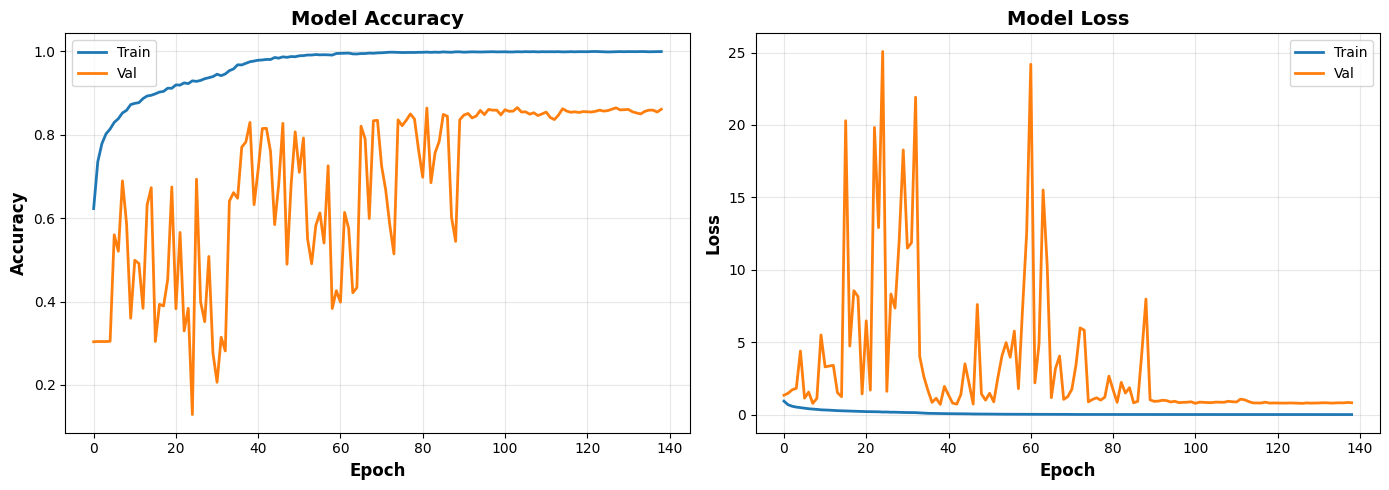


Best val accuracy: 86.55% at epoch 104


[15:57:53] WARNING  Compiled the loaded model, but the compiled metrics have yet to be built.   ]8;id=363635;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/legacy/saving/saving_utils.py\saving_utils.py]8;;\:]8;id=761020;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/legacy/saving/saving_utils.py#249\249]8;;\
                    `model.compile_metrics` will be empty until you train or evaluate the                          
                    model.                                                                                         


EVALUATION

Test Accuracy: 93.40%


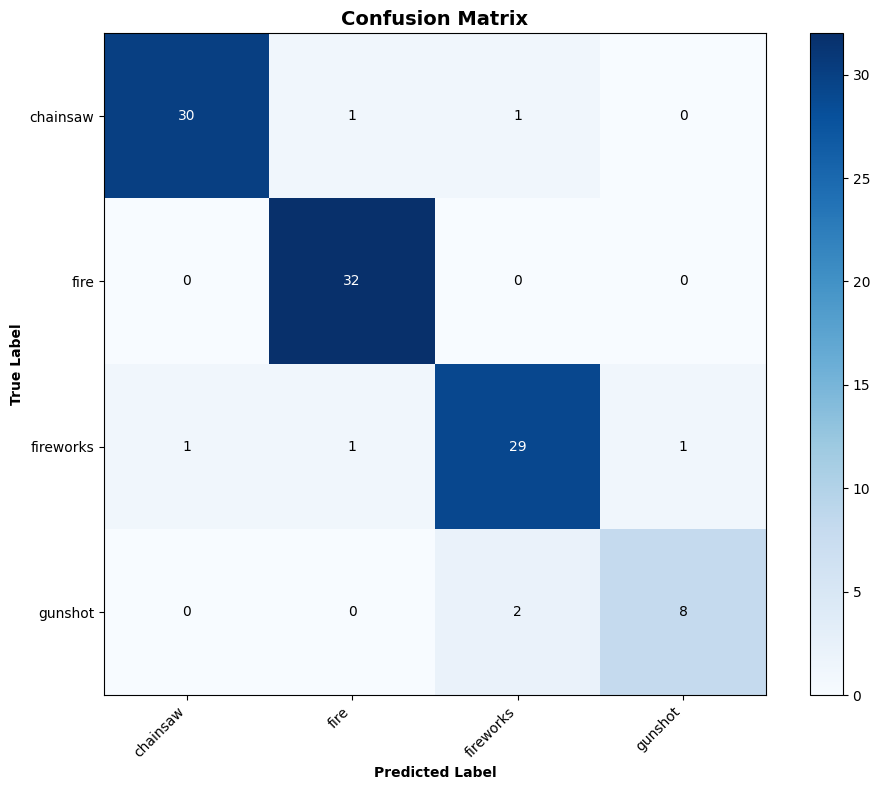


Per-Class Metrics:
Class            Precision     Recall         F1    Support
-----------------------------------------------------------------
chainsaw             0.968      0.938      0.952         32
fire                 0.941      1.000      0.970         32
fireworks            0.906      0.906      0.906         32
gunshot              0.889      0.800      0.842         10

Confidence Analysis:
  Mean confidence: 0.977
  Median confidence: 1.000

SAVING MODEL


[15:57:54] WARNING  You are saving your model as an HDF5 file via `model.save()` or                ]8;id=858180;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py\saving_api.py]8;;\:]8;id=435402;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/saving/saving_api.py#83\83]8;;\
                    `keras.saving.save_model(model)`. This file format is considered legacy. We                    
                    recommend using instead the native Keras format, e.g.                                          
                    `model.save('my_model.keras')` or `keras.saving.save_model(model,                              
                    'my_model.keras')`.                                                                            

Keras model saved: ./data/models/models_cnn/final_model.h5
INFO:tensorflow:Assets written to: /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmpx4kkk5dd/assets


[15:57:55] INFO     Assets written to:                                                          ]8;id=216958;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/tensorflow/python/saved_model/builder_impl.py\builder_impl.py]8;;\:]8;id=577546;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/tensorflow/python/saved_model/builder_impl.py#836\836]8;;\
                    /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmpx4kkk5dd/assets                            

Saved artifact at '/var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmpx4kkk5dd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 400), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  5544346896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5544351824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5544397280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5544398512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5544359744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5544394992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5544409600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5544407840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5544544912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5544542800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5544543152: TensorSpec(shape=(), dt

W0000 00:00:1772463476.305136  614057 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772463476.305149  614057 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-02 15:57:56.305309: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmpx4kkk5dd
2026-03-02 15:57:56.306576: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-02 15:57:56.306586: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmpx4kkk5dd
2026-03-02 15:57:56.319619: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-02 15:57:56.385502: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmpx4kkk5dd
2026-03-02 15:57:56.406766: I tensorflow/cc/saved_model/loader.cc:

In [96]:
dataset = Dataset()
dataset.remove_class("background")
dataset.remove_class("birds")
dataset.remove_class("handsaw")
dataset.remove_class("helicopter")
model, metrics, classnames = main_pipeline(dataset, config)